<a href="https://colab.research.google.com/github/sri-nikesh-1432/Web-Traffic-Analytics/blob/main/Web_Traffic_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# --- STEP 1: Generate Web Traffic Data ---
# Simulating a user journey: Home -> Pricing -> Signup -> Dashboard
np.random.seed(42)
num_sessions = 1000

pages = ['Home', 'Pricing', 'Signup', 'Dashboard']
traffic_data = []

for session_id in range(num_sessions):
    # Randomly decide how deep a user goes (Drop-off points)
    path_depth = np.random.choice([1, 2, 3, 4], p=[0.4, 0.3, 0.2, 0.1])

    for i in range(path_depth):
        traffic_data.append({
            'SessionID': session_id,
            'Page': pages[i],
            'Duration_Sec': np.random.randint(5, 300),
            'Is_Exit': 1 if i == path_depth - 1 else 0
        })

df_web = pd.DataFrame(traffic_data)

print("WEB TRAFFIC PREVIEW")
display(df_web.head(10))

WEB TRAFFIC PREVIEW


,SessionID,Page,Duration_Sec,Is_Exit
0,0,Home,275,1
1,1,Home,193,0
2,1,Pricing,25,0
3,1,Signup,107,1
4,2,Home,219,0
5,2,Pricing,92,1
6,3,Home,156,1
7,4,Home,262,0
8,4,Pricing,298,1
9,5,Home,281,1


In [5]:
# --- STEP 2: Calculate Key Metrics ---
print("\n KEY WEBSITE METRICS")

# 1. Total Page Views
total_views = len(df_web)
print(f"Total Page Views: {total_views}")

# 2. Avg Session Duration
avg_duration = df_web.groupby('SessionID')['Duration_Sec'].sum().mean()
print(f"Average Session Duration: {avg_duration:.2f} seconds")

# 3. Drop-off Points (Exit Rate per Page)
exit_rates = df_web.groupby('Page')['Is_Exit'].mean().reindex(pages)
print("\nExit Rates per Page (Drop-off Points):")
print(exit_rates)


 KEY WEBSITE METRICS
Total Page Views: 2022
Average Session Duration: 308.57 seconds

Exit Rates per Page (Drop-off Points):
Page
Home         0.391000
Pricing      0.495895
Signup       0.654723
Dashboard    1.000000
Name: Is_Exit, dtype: float64


/tmp/ipykernel_1155/1387976004.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=exit_rates.index, y=exit_rates.values, palette='magma')


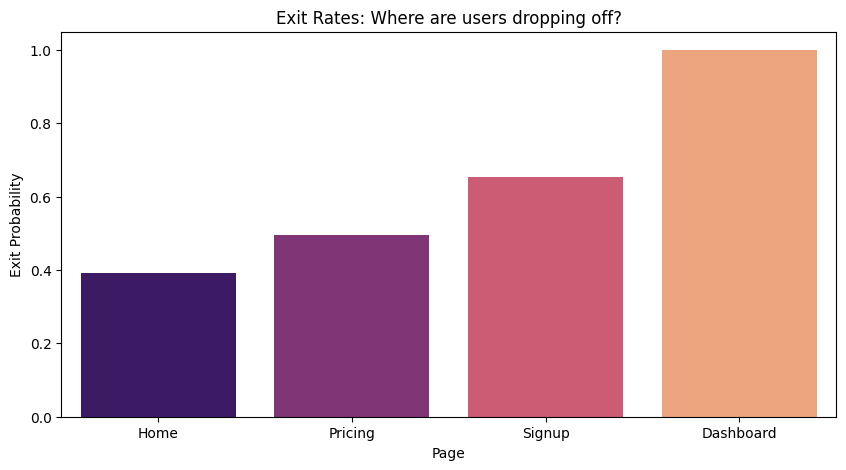

In [6]:
# --- STEP 3: Visualizing the User Journey ---
plt.figure(figsize=(10, 5))
sns.barplot(x=exit_rates.index, y=exit_rates.values, palette='magma')
plt.title('Exit Rates: Where are users dropping off?')
plt.ylabel('Exit Probability')
plt.show()

In [7]:
# --- STEP 4: Insight Generation ---
def engagement_insights(df):
    high_dropoff = exit_rates.idxmax()
    print(f"\nINSIGHT: The '{high_dropoff}' page has the highest drop-off rate.")
    print(f"SUGGESTION: Audit the '{high_dropoff}' page for technical errors or confusing UI.")

engagement_insights(df_web)


INSIGHT: The 'Dashboard' page has the highest drop-off rate.
SUGGESTION: Audit the 'Dashboard' page for technical errors or confusing UI.
